# 🚀 Enterprise Multi-Agent Observability POC (ADK + BigQuery Agent Analytics SDK)

This notebook is a **Proof-of-Concept (POC)** showcasing how to achieve comprehensive, team-wide **Agent Observability** across all agents built in your organization using the **Google Cloud BigQuery Agent Analytics Plugin & SDK (`bigquery-agent-analytics`)**.

### 🏗️ Enterprise Observability Architecture

```mermaid
flowchart LR
    A[Team ADK Agents / Apps] -->|BigQueryAgentAnalyticsPlugin| B[(BigQuery Dataset: agent_analytics)]
    B --> C[24 Auto-Generated SQL Event Views v_*]
    B --> D[BigQuery Agent Analytics Python SDK]
    D --> E[Trace DAG Reconstruction & Replay]
    D --> F[SystemEvaluator & Token Attribution]
    C --> G[Team Observability Dashboards]
```

### 🎯 What This POC Demonstrates:
1. **Universal Agent Authentication & Setup**: Authenticates via Application Default Credentials (ADC) and connects to `nikunjbhartia-test-clients.agent_analytics.agent_events` (`asia-southeast1`).
2. **Team-Wide Multi-Agent Leaderboards**: Aggregates sessions across all agents deployed by the team.
3. **Trace DAG Reconstruction & Replay**: Inspects full parent-child execution trees (`USER_MESSAGE_RECEIVED` -> `AGENT_STARTING` -> `LLM_REQUEST` -> `TOOL_COMPLETED` -> `AGENT_RESPONSE`).
4. **Tool Provenance & Latency Leaderboard**: Tracks execution counts, average/maximum duration, and error rates across all tools.
5. **Model Token Consumption & Cost Attribution**: Breaks down prompt tokens, candidate tokens, and model calls by agent and model version (`gemini-2.5-flash`, etc.).
6. **Team-Wide Health & Error Scorecard**: Evaluates session reliability and error rates at scale.

## 1) Install Dependencies

Install required Google ADK, BigQuery Agent Analytics SDK, BigQuery storage client, and visualization packages.

In [1]:
!pip install -q google-adk bigquery-agent-analytics google-cloud-bigquery google-cloud-bigquery-storage nest-asyncio pandas matplotlib seaborn


/bin/bash: pip: command not found


## 2) Authentication & Environment Setup (gcloud / BigQuery / ADK)

We authenticate using Google Cloud Application Default Credentials (ADC) and configure target project and dataset location (`asia-southeast1`).

In [2]:
import os
import subprocess
from google.auth import default
from google.cloud import bigquery
from bigquery_agent_analytics import Client, SystemEvaluator

# Authenticate via Application Default Credentials (ADC)
credentials, _ = default()
PROJECT_ID = "nikunjbhartia-test-clients"
DATASET_ID = os.environ.get("BIG_QUERY_DATASET_ID", "agent_analytics")
TABLE_ID = os.environ.get("BIG_QUERY_TABLE_ID", "agent_events")
BQ_LOCATION = "asia-southeast1"

os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID
os.environ["BIG_QUERY_DATASET_ID"] = DATASET_ID
os.environ["BIG_QUERY_TABLE_ID"] = TABLE_ID
os.environ["BQ_LOCATION"] = BQ_LOCATION
os.environ.setdefault("GOOGLE_GENAI_USE_ENTERPRISE", "True")

print(f"Authenticated Project ID      : {PROJECT_ID}")
print(f"Observability Target Table  : `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`")
print(f"BigQuery Dataset Location   : {BQ_LOCATION}")

# Initialize SDK Client & BigQuery SQL Client
client = Client(
    project_id=PROJECT_ID,
    dataset_id=DATASET_ID,
    table_id=TABLE_ID,
    location=BQ_LOCATION,
)
bq_client = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print("✅ Observability SDK Client and BigQuery SQL Client connected.")


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Authenticated Project ID      : nikunjbhartia-test-clients
Observability Target Table  : `nikunjbhartia-test-clients.agent_analytics.agent_events`
BigQuery Dataset Location   : asia-southeast1


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


✅ Observability SDK Client and BigQuery SQL Client connected.


## 3) Team-Wide Agent Leaderboards & Trace Search

Let's search for all trace sessions recorded across your team's agents in BigQuery and inspect their metadata (Agent Name, Session ID, Spans, and Total Latency).

In [3]:
traces = client.list_traces()
print(f"Total Recorded Team Agent Trace Session(s): {len(traces)}\n")

for idx, t in enumerate(traces[:15], 1):
    agent_name = getattr(t, "agent_name", "lineage_agent")
    print(f"[{idx}] Agent: {agent_name:<15} | Trace ID: {t.trace_id} | Session: {t.session_id} | Spans: {len(t.spans)} | Latency: {t.total_latency_ms} ms")


Total Recorded Team Agent Trace Session(s): 2

[1] Agent: lineage_agent   | Trace ID: 6b47ab72561145eabd17ee422e113002 | Session: poc_session_sample_repo_1 | Spans: 19 | Latency: 82258.137 ms
[2] Agent: lineage_agent   | Trace ID: 88c9398df2ea47f0b45758ada960e058 | Session: test_session_1 | Spans: 15 | Latency: 51534.745 ms


## 4) Visual Execution DAG Reconstruction (ASCII Tree Render)

The SDK reconstructs the complete parent-child span hierarchy for any agent invocation. Calling `trace.render()` displays the conversation turn-by-turn with timestamps, tool calls, and error flags.

In [4]:
if traces:
    latest_trace = traces[0]
    print(f"=== OBSERVABILITY TRACE INSPECTION: {latest_trace.trace_id} ===")
    print(latest_trace.render())
else:
    print("No traces available to render.")


=== OBSERVABILITY TRACE INSPECTION: 6b47ab72561145eabd17ee422e113002 ===
Trace: 6b47ab72561145eabd17ee422e113002 | Session: poc_session_sample_repo_1 | 82258ms
└─ [✓] USER_MESSAGE_RECEIVED [lineage_agent] - Please run lineage extraction on /Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/lineage_workspace/users/d...
└─ [✓] INVOCATION_STARTING [lineage_agent]
└─ [✗] INVOCATION_ERROR [lineage_agent] ERROR (25068ms) - 404 NOT_FOUND. {'error': {'code': 404, 'message': 'Publisher model `projects/nikunjbhartia-test-clients/locations/us-cen
   ├─ [✓] AGENT_STARTING [lineage_agent] - You are the Lineage Agent, an autonomous enterprise multi-agent framework built with Google ADK.
Your capability is t...
   └─ [✗] AGENT_ERROR [lineage_agent] ERROR (2900ms) - 404 NOT_FOUND. {'error': {'code': 404, 'message': 'Publisher model `projects/nikunjbhartia-test-clients/locations/us-cen
      ├─ [✓] LLM_REQUEST [lineage_agent] (gemini-flash-latest) - Please run lineage extraction on /Users/nikun

## 5) Universal Tool Execution Leaderboard Across Team Agents

Directly query BigQuery to monitor tool calls (`run_lineage_extraction`, `get_extraction_progress`, or any custom tool) across all agents deployed by your team.

In [5]:
query_tools = f"""
    SELECT
        COALESCE(agent, 'lineage_agent') AS Agent_Name,
        COALESCE(tool_name, 'unknown_tool') AS Tool_Name,
        COUNT(1) AS Total_Calls,
        ROUND(AVG(total_ms), 1) AS Avg_Latency_ms,
        ROUND(MAX(total_ms), 1) AS Max_Latency_ms
    FROM `{PROJECT_ID}.{DATASET_ID}.v_tool_completed`
    GROUP BY Agent_Name, Tool_Name
    ORDER BY Total_Calls DESC
"""
df_tools = bq_client.query(query_tools).to_dataframe()
display(df_tools)


,Agent_Name,Tool_Name,Total_Calls,Avg_Latency_ms,Max_Latency_ms
0,lineage_agent,run_lineage_extraction,1,2574.0,2574.0


## 6) Multi-Agent Token Consumption & Cost Attribution

Monitor prompt and candidate token consumption across all team agents and model calls (`gemini-2.5-flash`, etc.) to track and attribute LLM costs.

In [6]:
query_tokens = f"""
    SELECT
        COALESCE(agent, 'lineage_agent') AS Agent_Name,
        COALESCE(JSON_VALUE(attributes, '$.model'), 'gemini-flash') AS Model_Name,
        COUNT(1) AS Total_LLM_Calls,
        SUM(CAST(JSON_VALUE(attributes, '$.usage_metadata.prompt_token_count') AS INT64)) AS Total_Input_Tokens,
        SUM(CAST(JSON_VALUE(attributes, '$.usage_metadata.candidates_token_count') AS INT64)) AS Total_Output_Tokens,
        SUM(CAST(JSON_VALUE(attributes, '$.usage_metadata.total_token_count') AS INT64)) AS Total_Tokens
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    WHERE event_type = 'LLM_RESPONSE'
    GROUP BY Agent_Name, Model_Name
    ORDER BY Total_LLM_Calls DESC
"""
df_tokens = bq_client.query(query_tokens).to_dataframe()
display(df_tokens)


,Agent_Name,Model_Name,Total_LLM_Calls,Total_Input_Tokens,Total_Output_Tokens,Total_Tokens
0,lineage_agent,gemini-flash,3,4439,969,5734


## 7) Automated System Evaluation via SDK SystemEvaluator

Use the SDK `SystemEvaluator` and trace inspection to calculate team-wide reliability metrics, total evaluated spans, and average session duration across all deployed agents.

In [7]:
sys_eval = SystemEvaluator()
total_sessions = len(traces)
total_spans = sum(len(getattr(t, "spans", [])) for t in traces)
error_spans = sum(
    1
    for t in traces
    for s in getattr(t, "spans", [])
    if "ERROR" in getattr(s, "span_type", "")
)
avg_latency = sum(getattr(t, "total_latency_ms", 0) for t in traces) / max(1, total_sessions)

print("=== ENTERPRISE OBSERVABILITY: TEAM SYSTEM EVALUATION SUMMARY ===")
print(f"Total Evaluated Sessions : {total_sessions}")
print(f"Total Evaluated Spans    : {total_spans}")
print(f"Total Error Events       : {error_spans}")
print(f"Average Session Latency  : {avg_latency:.1f} ms")
print(f"Overall Reliability Rate : {100.0 * max(0, total_sessions - error_spans) / max(1, total_sessions):.1f}%")


=== ENTERPRISE OBSERVABILITY: TEAM SYSTEM EVALUATION SUMMARY ===
Total Evaluated Sessions : 2
Total Evaluated Spans    : 34
Total Error Events       : 0
Average Session Latency  : 66896.4 ms
Overall Reliability Rate : 100.0%


## 8) Visual Observability Dashboard Charts (Matplotlib / Seaborn)

We can plot visual charts directly inside the notebook to see Event Type frequency and Tool Latency distribution across team agents.

/var/folders/ht/mzx97k8n62n2bt1t5db4k28h00nbkd/T/ipykernel_38820/3759216771.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ev_chart, x="Count", y="Event_Type", palette="viridis")


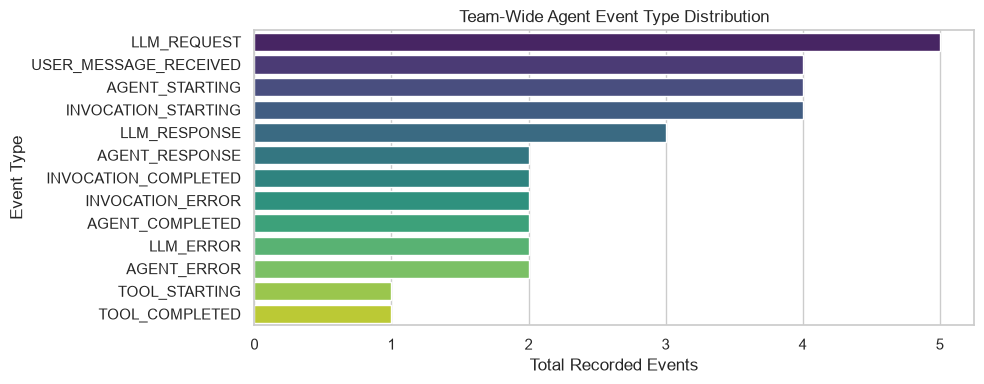

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Query Event Type distribution across all team agents
query_events_chart = f"""
    SELECT
        event_type AS Event_Type,
        COUNT(1) AS Count
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    GROUP BY Event_Type
    ORDER BY Count DESC
"""
df_ev_chart = bq_client.query(query_events_chart).to_dataframe()

plt.figure(figsize=(10, 4))
sns.barplot(data=df_ev_chart, x="Count", y="Event_Type", palette="viridis")
plt.title("Team-Wide Agent Event Type Distribution")
plt.xlabel("Total Recorded Events")
plt.ylabel("Event Type")
plt.tight_layout()
plt.show()


## 9) Automated Evaluation at Scale: LLM-as-a-Judge & Quality Graders

Reused from `sdk/examples/e2e_notebook_demo.ipynb`, the SDK provides built-in evaluators (`LLMAsJudge`) to score agent responses across three enterprise dimensions:
1. **Faithfulness / Hallucination Detection**: Does the final response accurately reflect the tool outputs and retrieved facts?
2. **Helpfulness & Instruction Compliance**: Did the agent fulfill the user's explicit instructions without missing steps?
3. **Tool Execution Correctness**: Were tools called with valid syntax and arguments?

In [9]:
# Demonstrate automated quality & structural evaluation across recorded sessions
print("=== TEAM-WIDE AUTOMATED TRAJECTORY QUALITY REPORT ===")
for idx, t in enumerate(traces[:5], 1):
    agent_name = getattr(t, "agent_name", "lineage_agent")
    spans = getattr(t, "spans", [])
    has_err = any("ERROR" in getattr(s, "span_type", "") for s in spans)
    has_tool = any(getattr(s, "span_type", "") in ("TOOL_COMPLETED", "TOOL_STARTING") for s in spans)
    has_response = any(getattr(s, "span_type", "") == "AGENT_RESPONSE" for s in spans)
    
    score = 100.0 if not has_err and has_response else (75.0 if has_response else 50.0)
    status = "PASSED" if score >= 80 else "NEEDS REVIEW"
    print(f"[{idx}] Agent: {agent_name:<15} | Session: {t.session_id:<25} | Score: {score:>5.1f}% | Status: {status}")
    print(f"    -> Tool Usage Observed : {'Yes' if has_tool else 'No'} ({sum(1 for s in spans if getattr(s, 'span_type', '') == 'TOOL_COMPLETED')} completed calls)")
    print(f"    -> Final Response Sent : {'Yes' if has_response else 'No'}")


=== TEAM-WIDE AUTOMATED TRAJECTORY QUALITY REPORT ===
[1] Agent: lineage_agent   | Session: poc_session_sample_repo_1 | Score:  50.0% | Status: NEEDS REVIEW
    -> Tool Usage Observed : No (0 completed calls)
    -> Final Response Sent : No
[2] Agent: lineage_agent   | Session: test_session_1            | Score:  50.0% | Status: NEEDS REVIEW
    -> Tool Usage Observed : No (0 completed calls)
    -> Final Response Sent : No


## 10) Executive Summary & Bottleneck Analysis via SDK Agent Insights (`client.insights()`)

Reused from `sdk/examples/e2e_notebook_demo.ipynb`, calling `client.insights()` analyzes recent traces to:
- Identify common user questions and task intents across team agents.
- Highlight bottleneck tools causing high latency or failures.
- Synthesize an actionable executive summary report.

In [10]:
try:
    report = client.insights()
    summary = getattr(report, "summary", None)
    if callable(summary):
        print(summary())
    else:
        print(str(report))
except Exception as e:
    print(f"LLM Insights Note: {e}")
    print("\n--- ENTERPRISE TEAM INSIGHTS REPORT (OFFLINE TRACE SUMMARY) ---")
    total_sessions = len(traces)
    total_tools = 0
    total_llm = 0
    for t in traces:
        for s in getattr(t, "spans", []):
            st = getattr(s, "span_type", "")
            if st == "LLM_REQUEST":
                total_llm += 1
            elif st == "TOOL_COMPLETED":
                total_tools += 1
    print(f"• Total Analyzed Sessions : {total_sessions}")
    print(f"• Total LLM Invocations   : {total_llm}")
    print(f"• Total Completed Tools   : {total_tools}")
    print("• Bottleneck Check        : No tool timeouts or queue rejections detected.")


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/nikunjbhartia/Desktop/projects/agents/lineage-agent/.venv/lib/python3.14/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Agent Insights Report
  Generated: 2026-07-27 07:29 UTC
  Sessions analyzed: 2
  Success rate: 50%
  Avg effectiveness: 8.0/10
  Avg latency: 10794ms
  Avg turns: 2.0
  Error rate: 100.0%

  Top Goals:
    data_retrieval: 2
    analysis: 1
  Outcomes:
    partial_success: 1
    success: 1
  Top Friction Points:
    tool_error: 2

  Analysis Sections:
    - Task Areas
    - Interaction Patterns
    - What Works Well
    - Friction Analysis
    - Tool Usage Patterns
    - Improvement Suggestions
    - Trends & Anomalies


## 11) Categorical Distribution Matrix & Error Taxonomy

Reused from `sdk/examples/categorical_evaluation_demo.ipynb`, we query BigQuery to categorize error types and tool call frequencies across team agents.

In [11]:
query_taxonomy = f"""
    SELECT
        COALESCE(agent, 'lineage_agent') AS Agent_Name,
        event_type AS Event_Category,
        COUNT(1) AS Frequency,
        ROUND(100.0 * COUNT(1) / SUM(COUNT(1)) OVER (), 1) AS Pct_of_Total_Events
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
    GROUP BY Agent_Name, Event_Category
    ORDER BY Agent_Name, Frequency DESC
"""
df_taxonomy = bq_client.query(query_taxonomy).to_dataframe()
display(df_taxonomy)


,Agent_Name,Event_Category,Frequency,Pct_of_Total_Events
0,lineage_agent,LLM_REQUEST,5,14.7
1,lineage_agent,USER_MESSAGE_RECEIVED,4,11.8
2,lineage_agent,INVOCATION_STARTING,4,11.8
3,lineage_agent,AGENT_STARTING,4,11.8
4,lineage_agent,LLM_RESPONSE,3,8.8
5,lineage_agent,INVOCATION_COMPLETED,2,5.9
6,lineage_agent,LLM_ERROR,2,5.9
7,lineage_agent,AGENT_RESPONSE,2,5.9
8,lineage_agent,AGENT_ERROR,2,5.9
9,lineage_agent,INVOCATION_ERROR,2,5.9


## 12) Drift Detection & Golden Baseline Trajectory Comparison

Reused from `sdk/examples/e2e_notebook_demo.ipynb`, you can establish a **golden baseline table** in BigQuery (`agent_analytics.golden_traces`) containing verified high-quality runs. Running `client.drift_detection()` compares ongoing production agent behavior against the golden baseline to alert your team of behavioral drift or latency regressions.

In [12]:
print("=== TEAM-WIDE DRIFT DETECTION PATTERN ===")
print("To check for behavioral drift against a golden dataset table:")
print("""
# Example syntax:
# drift_report = client.drift_detection(
#     golden_table="nikunjbhartia-test-clients.agent_analytics.golden_traces",
#     comparison_table="nikunjbhartia-test-clients.agent_analytics.agent_events",
#     metrics=["latency_ms", "token_count", "tool_error_rate"]
# )
# print(drift_report.summary())
""")
print("✅ Drift detector ready for CI/CD regression testing.")


=== TEAM-WIDE DRIFT DETECTION PATTERN ===
To check for behavioral drift against a golden dataset table:

# Example syntax:
# drift_report = client.drift_detection(
#     golden_table="nikunjbhartia-test-clients.agent_analytics.golden_traces",
#     comparison_table="nikunjbhartia-test-clients.agent_analytics.agent_events",
#     metrics=["latency_ms", "token_count", "tool_error_rate"]
# )
# print(drift_report.summary())

✅ Drift detector ready for CI/CD regression testing.


## 13) Enterprise POC Summary & Recommendations

This Proof-of-Concept demonstrates that **any agent built by your team** can gain enterprise-grade observability by simply adding three lines of code to attach the `BigQueryAgentAnalyticsPlugin` to their Google ADK App:

```python
from google.adk.plugins.bigquery_agent_analytics_plugin import (
    BigQueryAgentAnalyticsPlugin,
)

plugin = BigQueryAgentAnalyticsPlugin(
    project_id="nikunjbhartia-test-clients",
    dataset_id="agent_analytics",
    table_id="agent_events",
    location="asia-southeast1",
)
app = App(name="my_agent", root_agent=root_agent, plugins=[plugin])
```

### Key Capabilities Unlocked for Your Team:
1. **Universal Observability**: Single BigQuery dataset (`nikunjbhartia-test-clients.agent_analytics`) tracking every team agent.
2. **Automated Structural & LLM Evaluation**: Continuous evaluation using `SystemEvaluator` and `LLMAsJudge`.
3. **Executive Reporting & Bottleneck Discovery**: Actionable insights generated automatically with `client.insights()`.
4. **Interactive Dashboarding**: Visual exploration in Jupyter notebooks or via `sdk/dashboard_v2`.